# Präsentation — Copy-Up-Grafiken (Stufe 0)

Grafiken für den Copy-Up-Teil:

1. **Spektrogramm-Tripel** Bandbegrenzt / Copy-Up / Original für mehrere Beispiele.
2. **Crossover-Zoom** auf die „Naht" am 8-kHz-Cutoff.
3. **Frequenzgänge einzelner STFT-Frames** (komprimierte Magnitude, wie in `01_dsp`) —
   macht die Kachel-Kopie des 4–8-kHz-Quellbands unmittelbar sichtbar.

Auswahl unten anpassen; `SAVE=True` schreibt PNGs nach `praesentation/plots/`.

In [1]:
import os
# MÜSSEN vor dem TensorFlow-Import gesetzt sein (oneDNN-Crash-Fix + leise Logs).
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from bwe import config as cfg
from bwe.dsp.stft import stft, drop_nyquist
from bwe.dsp.compress import compress
from bwe.data.loaders import load_demo
from bwe.infer.reconstruct import baseline_from_fullband
from bwe.eval import plots as P

# >>> Export-Ziel für die Präsentations-Dateien <<<
SAVE   = True                # False = nur anzeigen, nichts speichern
ASSETS = Path(os.environ.get("BWE_PRAES_DIR",
    r"C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation"))

def save_fig(fig, name, subdir="plots"):
    """Figur als PNG in den Präsentations-Ordner schreiben (nur wenn SAVE=True)."""
    if SAVE:
        p = ASSETS / subdir / name
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=200, bbox_inches="tight")
        print("  gespeichert:", p)

print(cfg.summary())

SR=32000 Hz | N_FFT=1024 HOP=256 | 31.250 Hz/Bin
Bins: full=513 net=512 | Cutoffs=(8000,) Hz | Standard 8000 Hz -> Bin 256
Copy-Up-Quellband = Bins 128..256
Segment: 128 Frames = 33536 Samples (~1.048 s)
DATA_ROOT=C:\Users\danyr\bwe_data\musdb18hq_32k


## Beispiele laden

`CU_DEMOS` = Liste `(split, index, offset_s, dauer_s)` — die Rekonstruktionen werden
einmal gerechnet und von allen Plot-Zellen wiederverwendet.

In [2]:
# >>> Beispiel-Tracks — frei anpassbar <<<
CU_DEMOS = [
    ("test",  0, 30.0, 8.0),
    ("test", 12, 60.0, 8.0),
    ("test", 30, 45.0, 8.0),
]

results = []
for split, index, offset, seconds in CU_DEMOS:
    name, target = load_demo(split, index, seconds=seconds, offset=offset)
    cu, inp = baseline_from_fullband(target)
    results.append({"key": f"{split}{index:02d}", "name": name,
                    "target": target, "cu": cu, "inp": inp})
    print(f"{split}[{index}] {name}")

test[0] Al James - Schoolboy Facination
test[12] Enda Reilly - Cur An Long Ag Seol


test[30] Raft Monk - Tiring


## 1. Spektrogramm-Tripel (Bandbegrenzt / Copy-Up / Original)

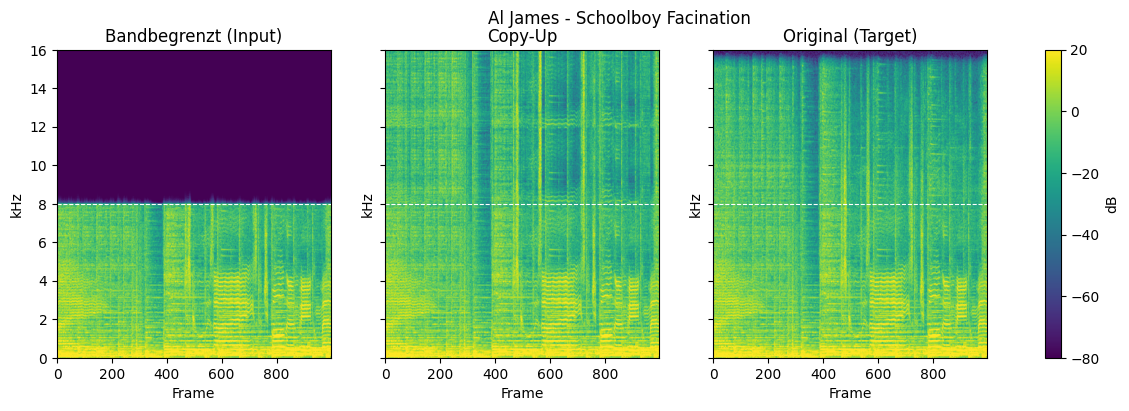

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\copyup_tripel_test00.png


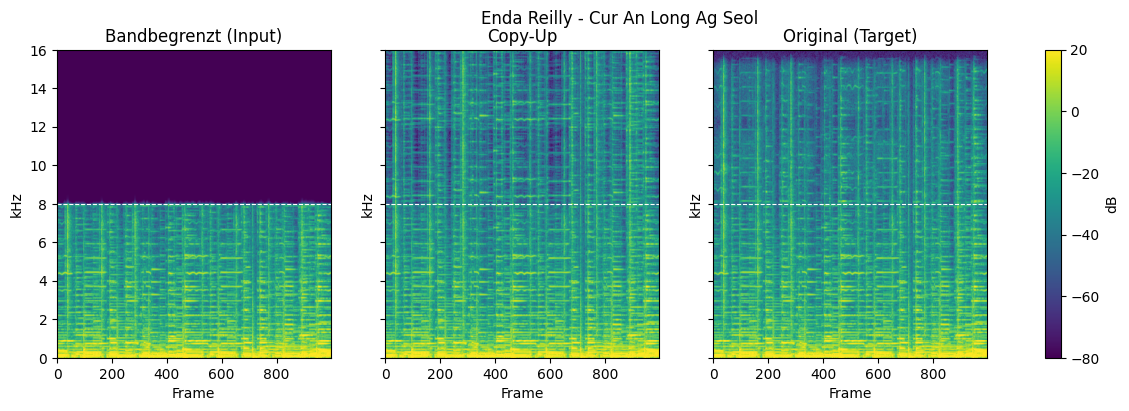

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\copyup_tripel_test12.png


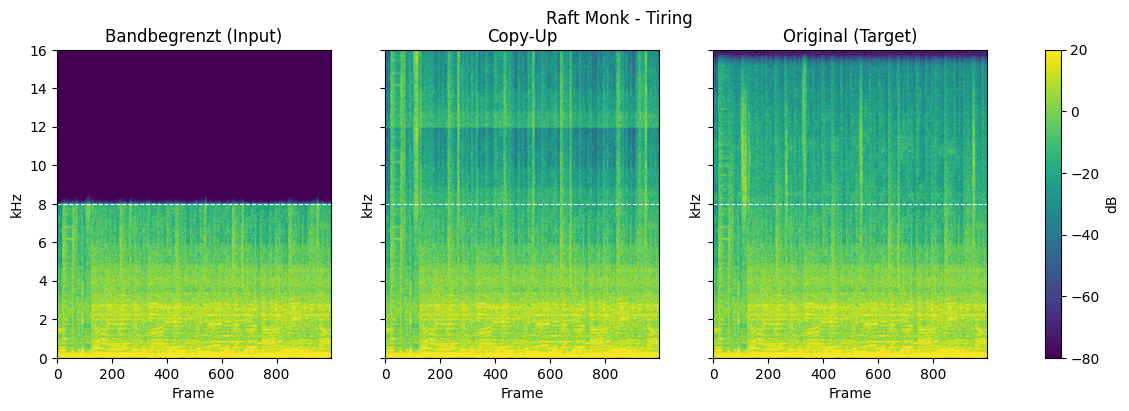

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\copyup_tripel_test30.png


In [3]:
for r in results:
    fig = P.spectro_triple(r["inp"], r["cu"], r["target"],
                           titles=("Bandbegrenzt (Input)", "Copy-Up", "Original (Target)"))
    fig.suptitle(r["name"])
    plt.show()
    save_fig(fig, f"copyup_tripel_{r['key']}.png")

## 2. Crossover-Zoom (die „Naht")

Zoom um den 8-kHz-Cutoff: links die Copy-Up-Rekonstruktion (Kopierkante sichtbar),
rechts das Original.

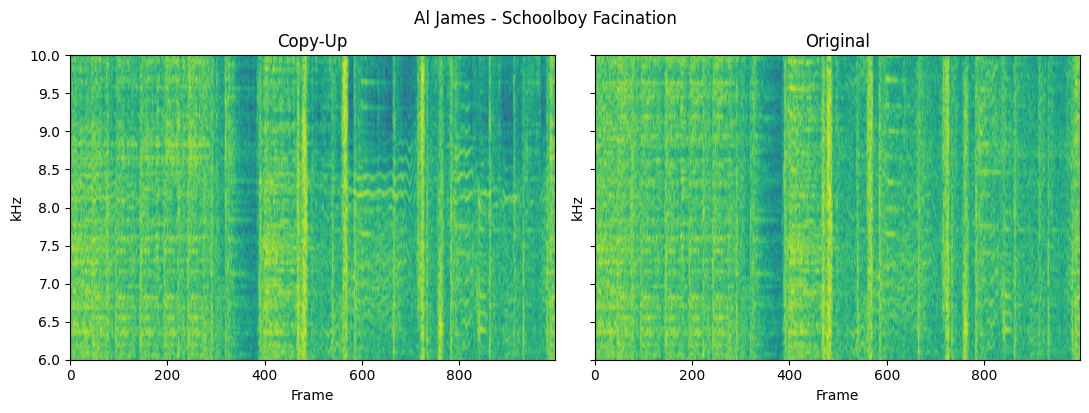

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\copyup_crossover_test00.png


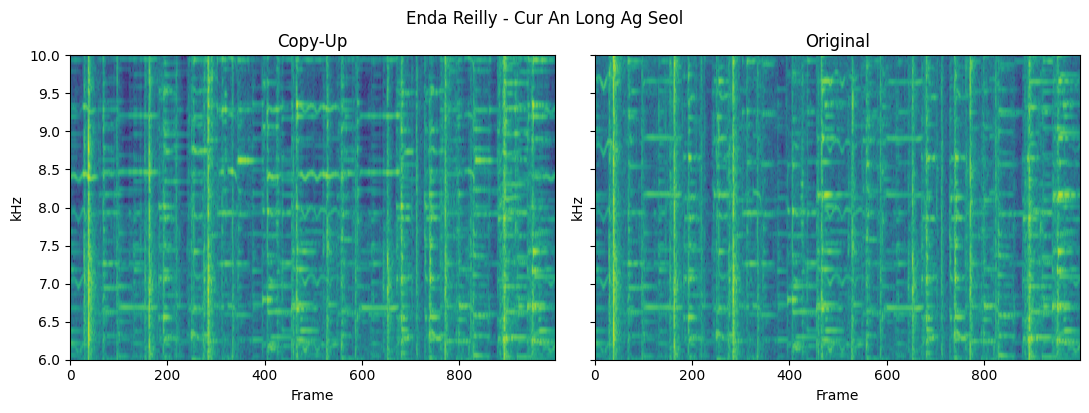

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\copyup_crossover_test12.png


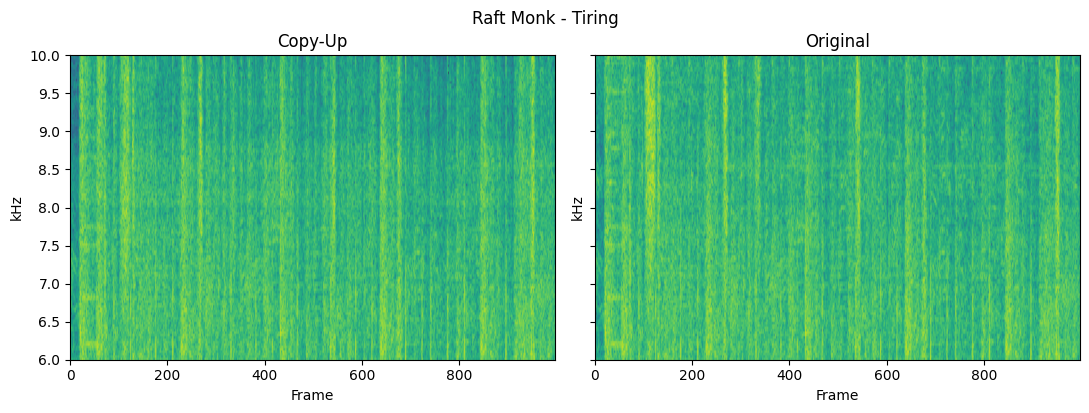

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\copyup_crossover_test30.png


In [4]:
for r in results:
    fig = P.crossover_zoom(r["cu"], r["target"], titles=("Copy-Up", "Original"))
    fig.suptitle(r["name"], y=1.02)
    plt.show()
    save_fig(fig, f"copyup_crossover_{r['key']}.png")

## 3. Frequenzgänge einzelner STFT-Frames

Ein einzelner Zeit-Frame als Frequenzgang (komprimierte Magnitude): das leere HF-Band
vor dem Copy-Up, die zwei Kopien des 4–8-kHz-Quellbands danach, das Original als
Referenz. `T0S` = Frame-Indizes (Frame ≈ 8 ms Hop) — Frames mit deutlichem HF-Inhalt
wählen.

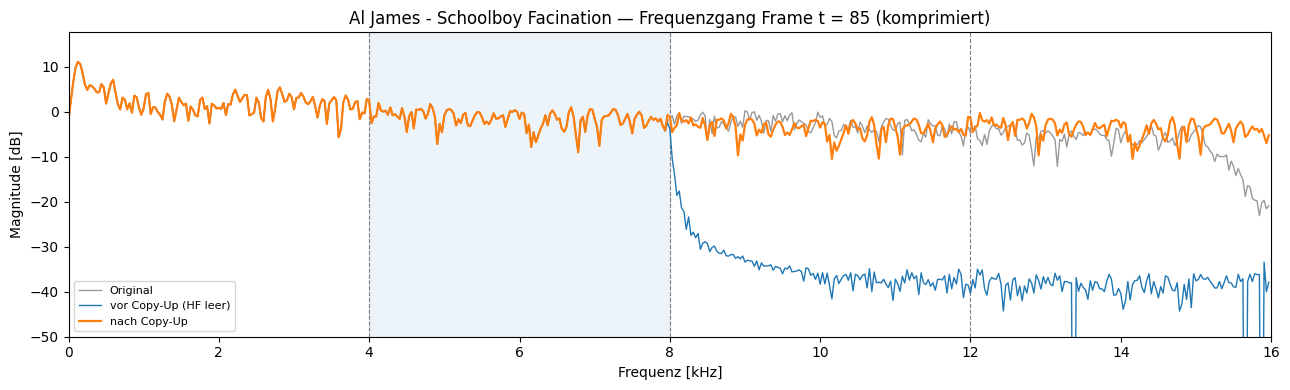

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\copyup_frequenzgang_test00_t85.png


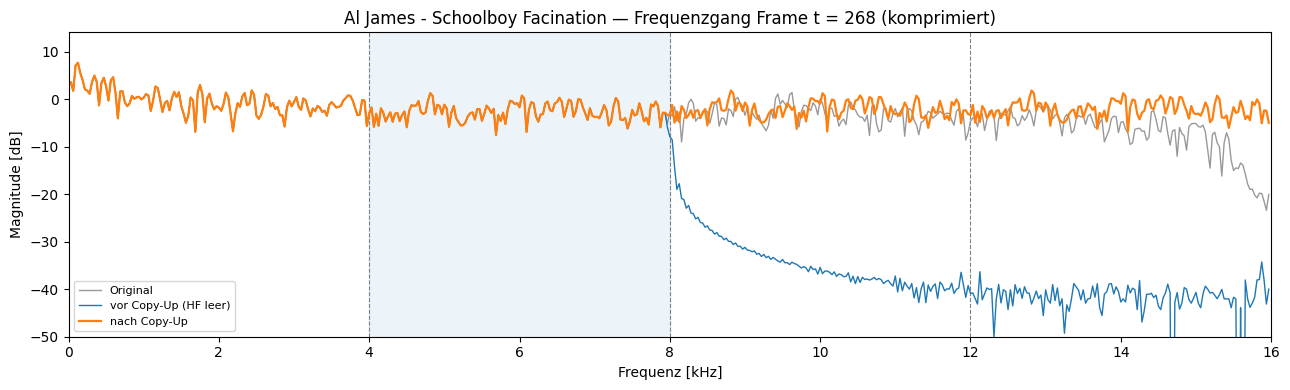

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\copyup_frequenzgang_test00_t268.png


In [5]:
# >>> Frame-Auswahl (Indizes in die 8-s-Ausschnitte) <<<
T0S = (85, 268)

for r in results[:1]:                      # Standard: nur das erste Beispiel — anpassen
    spec_band = drop_nyquist(compress(stft(r["inp"])))
    spec_cu = drop_nyquist(compress(stft(r["cu"])))
    spec_tg = drop_nyquist(compress(stft(r["target"])))
    for t0 in T0S:
        fig = P.frame_response(
            [("Original", spec_tg, dict(color="0.6", lw=1.0)),
             ("vor Copy-Up (HF leer)", spec_band, dict(color="C0", lw=1.0)),
             ("nach Copy-Up", spec_cu, dict(color="C1", lw=1.6))],
            t0=t0, mark_bands=True,
            title=f"{r['name']} — Frequenzgang Frame t = {t0} (komprimiert)")
        plt.show()
        save_fig(fig, f"copyup_frequenzgang_{r['key']}_t{t0}.png")